
# Baseline Model: TF-IDF + Logistic Regression

This notebook builds a baseline for predicting the six Jigsaw toxicity labels. Comments can have multiple labels, so each label is treated as a separate binary classification task.

We reuse the saved 70/15/15 train, validation, and test partitions. TF-IDF is fitted only on training comments, and logistic regression uses balanced class weights to address label imbalance.

Validation performance is measured using average precision for each label, alongside its positive count. The test partition is reserved for final evaluation after model settings and decision thresholds are fixed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import joblib 

df = pd.read_csv("../data/raw/train.csv")
test_ids = pd.read_csv("../data/processed/test_ids.csv")
train_ids = pd.read_csv("../data/processed/train_ids.csv")
validation_ids = pd.read_csv("../data/processed/validation_ids.csv")
run_id = 'baseline_v1_full_train'

labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Matplotlib is building the font cache; this may take a moment.


In [2]:
test_ids['partition'] = 'test'
train_ids['partition'] = 'train'
validation_ids['partition'] = 'validation'
id_maps = pd.concat([test_ids, train_ids, validation_ids])
id_maps

,id,partition
0,000113f07ec002fd,test
1,00040093b2687caa,test
2,0006f16e4e9f292e,test
3,00078f8ce7eb276d,test
4,0009801bd85e5806,test
...,...,...
23931,ff9ae4a64d2d5de1,validation
23932,ffb47123b2d82762,validation
23933,ffbdbb0483ed0841,validation
23934,ffc2f409658571f1,validation


In [3]:
df = df.merge(
    on = 'id',
    how = 'left',
    validate = '1:1',
    right = id_maps 
)

In [4]:
missing_partitions = df['partition'].isna()
blank_partitions = df['partition'].fillna('').str.strip().eq('')

print("Missing:", missing_partitions.sum())
print("Blank, excluding missing:", (blank_partitions & ~missing_partitions).sum())
print("Total Count: ", df['partition'].value_counts())

Missing: 0
Blank, excluding missing: 0
Total Count:  partition
train         111699
test           23936
validation     23936
Name: count, dtype: int64


In [5]:
label_sums = df.groupby('partition')[labels].sum()

label_sums = label_sums.loc[['train', 'validation', 'test']].T
label_sums

partition,train,validation,test
toxic,10706,2294,2294
severe_toxic,1116,240,239
obscene,5914,1267,1268
threat,335,71,72
insult,5514,1182,1181
identity_hate,983,211,211


Added a partition column mapped to the source dataset

Validated the results to make sure they match our expected values

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    analyzer = 'word',
    ngram_range=(1,1),
    max_features=30000,
    min_df = 2,
    max_df = 1.0,
    lowercase = True,
    stop_words= None,
    sublinear_tf = True,
    norm = 'l2'
)

Created the vectorizer: utilizing TfidVectorizer from sci-kit learn: Comments are represented using word level TF-IDF features. 

In [7]:
train_mask = df['partition'].eq('train')
val_mask = df['partition'].eq('validation')

X_train = vectorizer.fit_transform(
    df.loc[train_mask, 'comment_text']
)

X_val = vectorizer.transform(
    df.loc[val_mask, 'comment_text']
)

print(X_train.shape)
print(X_val.shape)
from scipy.sparse import issparse

assert issparse(X_train) and issparse(X_val)
assert np.isfinite(X_train.data).all()
assert np.isfinite(X_val.data).all()
assert 0 < len(vectorizer.vocabulary_) <= 30000
assert X_train.shape[1] == X_val.shape[1]

(111699, 30000)
(23936, 30000)


Shape is as expected: 111699 rows for train, 23936 for validation. Assertions ran as well

In [8]:
from sklearn.linear_model import LogisticRegression

toxic_model = LogisticRegression(
    class_weight = 'balanced',
    C = 1.0,
    solver = 'liblinear',
    max_iter = 200,
    random_state = 42
)

y_train_toxic = df.loc[train_mask, 'toxic']
toxic_model.fit(X_train, y_train_toxic)

toxic_scores = toxic_model.predict_proba(X_val)
print(toxic_model.classes_)
print(toxic_scores.shape)

[0 1]
(23936, 2)


In [9]:
severe_toxic_model = LogisticRegression(
    class_weight = 'balanced',
    C = 1.0,
    solver = 'liblinear',
    max_iter = 200,
    random_state = 42
)

y_train_severe_toxic = df.loc[train_mask, 'severe_toxic']
severe_toxic_model.fit(X_train, y_train_severe_toxic)

severe_toxic_scores = severe_toxic_model.predict_proba(X_val)
print(severe_toxic_model.classes_)
print(severe_toxic_scores.shape)

[0 1]
(23936, 2)


In [10]:
obscene_model = LogisticRegression(
    class_weight = 'balanced',
    C = 1.0,
    solver = 'liblinear',
    max_iter = 200,
    random_state = 42
)

y_train_obscene = df.loc[train_mask, 'obscene']
obscene_model.fit(X_train, y_train_obscene)

obscene_scores = obscene_model.predict_proba(X_val)
print(obscene_model.classes_)
print(obscene_scores.shape)

[0 1]
(23936, 2)


In [11]:
threat_model = LogisticRegression(
    class_weight = 'balanced',
    C = 1.0,
    solver = 'liblinear',
    max_iter = 200,
    random_state = 42
)

y_train_threat = df.loc[train_mask, 'threat']
threat_model.fit(X_train, y_train_threat)

threat_scores = threat_model.predict_proba(X_val)
print(threat_model.classes_)
print(threat_scores.shape)

[0 1]
(23936, 2)


In [12]:
insult_model = LogisticRegression(
    class_weight = 'balanced',
    C = 1.0,
    solver = 'liblinear',
    max_iter = 200,
    random_state = 42
)

y_train_insult = df.loc[train_mask, 'insult']
insult_model.fit(X_train, y_train_insult)

insult_scores = insult_model.predict_proba(X_val)
print(insult_model.classes_)
print(insult_scores.shape)

[0 1]
(23936, 2)


In [13]:
identity_hate_model = LogisticRegression(
    class_weight = 'balanced',
    C = 1.0,
    solver = 'liblinear',
    max_iter = 200,
    random_state = 42
)

y_train_identity_hate = df.loc[train_mask, 'identity_hate']
identity_hate_model.fit(X_train, y_train_identity_hate)

identity_hate_scores = identity_hate_model.predict_proba(X_val)
print(identity_hate_model.classes_)
print(identity_hate_scores.shape)

[0 1]
(23936, 2)


In [14]:
scores = pd.DataFrame(
    {
        'toxic': toxic_scores[:, 1],
        'severe_toxic': severe_toxic_scores[:, 1],
        'obscene': obscene_scores[:, 1],
        'threat': threat_scores[:, 1],
        'insult': insult_scores[:, 1],
        'identity_hate': identity_hate_scores[:, 1],
    },
    index=df.loc[val_mask, 'id']
)
display(scores)

assert scores.shape == (23936, 6)
assert scores.columns.tolist() == labels         
assert scores.index.is_unique
assert scores.to_numpy().min() >= 0 and scores.to_numpy().max() <= 1
assert np.isfinite(scores.to_numpy()).all()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
id,,,,,,
00025465d4725e87,0.036522,0.003304,0.012716,0.000346,0.019521,0.014522
00037261f536c51d,0.169353,0.001014,0.056712,0.001407,0.062409,0.002171
00054a5e18b50dd4,0.181221,0.010720,0.057935,0.016160,0.034516,0.027794
000897889268bc93,0.011182,0.006928,0.029143,0.001471,0.015070,0.004933
0009eaea3325de8c,0.053230,0.001967,0.020683,0.007746,0.037148,0.008887
...,...,...,...,...,...,...
ff9ae4a64d2d5de1,0.014130,0.003097,0.013632,0.000483,0.005151,0.013492
ffb47123b2d82762,0.999814,0.509782,0.999357,0.427622,0.992020,0.509399
ffbdbb0483ed0841,0.999999,0.994630,1.000000,0.931800,0.999986,0.934557


## Validation evaluation: average precision per label

Each model gives a separate score for one label. Average precision (AP) measures how well it ranks positive comments above negative comments on the validation set.

We report each label's positive count and prevalence alongside AP. Prevalence gives a constant-score reference for comparison. AP measures ranking; it does not tell us which threshold to use or whether the scores are calibrated probabilities.

In [15]:
y_val = df.loc[val_mask].set_index('id')[labels]
y_val = y_val.loc[scores.index]

assert y_val.index.equals(scores.index)
assert y_val.shape == (23936, 6)
y_val

,toxic,severe_toxic,obscene,threat,insult,identity_hate
id,,,,,,
00025465d4725e87,0,0,0,0,0,0
00037261f536c51d,0,0,0,0,0,0
00054a5e18b50dd4,0,0,0,0,0,0
000897889268bc93,0,0,0,0,0,0
0009eaea3325de8c,0,0,0,0,0,0
...,...,...,...,...,...,...
ff9ae4a64d2d5de1,0,0,0,0,0,0
ffb47123b2d82762,1,0,0,0,1,0
ffbdbb0483ed0841,1,0,1,0,1,0


In [16]:
from sklearn.metrics import average_precision_score

records = []
for label in labels:
    y_true = y_val[label]
    y_score = scores[label]

    support = int(y_true.sum())
    n = len(y_true)
    prevalence = support / n
    ap = average_precision_score(y_true, y_score)

    records.append({
        'run_id' : run_id,
        'label' : label,
        'n' : n,
        'support' : support,
        'prevalence' : prevalence,
        'ap' : ap,
        'ap_minus_prev' : ap - prevalence,
        'ap_over_prev' : ap / prevalence
    })

d1 = pd.DataFrame(records)

assert len(d1) == 6
assert d1['label'].tolist() == labels
assert np.isfinite(d1['ap']).all()
assert d1['ap'].between(0, 1).all()
assert d1['support'].tolist() == y_val[labels].sum().tolist()

print(d1.round(4))

macro_ap = d1['ap'].mean()
print(f"\nMacro AP: {macro_ap:.4f}")



                   run_id          label      n  support  prevalence      ap  \
0  baseline_v1_full_train          toxic  23936     2294      0.0958  0.8629   
1  baseline_v1_full_train   severe_toxic  23936      240      0.0100  0.4315   
2  baseline_v1_full_train        obscene  23936     1267      0.0529  0.8812   
3  baseline_v1_full_train         threat  23936       71      0.0030  0.5045   
4  baseline_v1_full_train         insult  23936     1182      0.0494  0.7747   
5  baseline_v1_full_train  identity_hate  23936      211      0.0088  0.4182   

   ap_minus_prev  ap_over_prev  
0         0.7671        9.0039  
1         0.4214       43.0313  
2         0.8282       16.6470  
3         0.5015      170.0668  
4         0.7254       15.6889  
5         0.4094       47.4373  

Macro AP: 0.6455


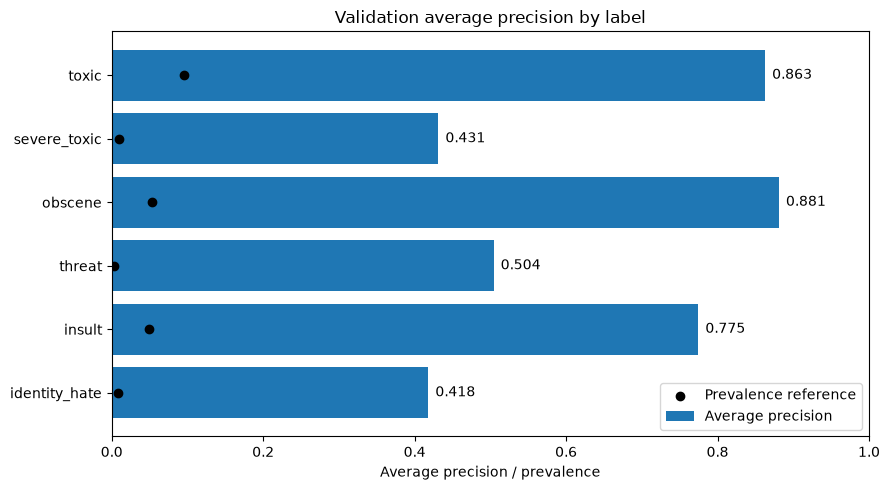

In [17]:
from pathlib import Path

fig, ax = plt.subplots(figsize=(9, 5))
positions = np.arange(len(d1))
bars = ax.barh(positions, d1['ap'], label='Average precision')
ax.scatter(d1['prevalence'], positions, color='black', marker='o',
           label='Prevalence reference', zorder=3)
ax.set_yticks(positions, d1['label'])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel('Average precision / prevalence')
ax.set_title('Validation average precision by label')
ax.legend(loc='lower right')

for bar, ap in zip(bars, d1['ap']):
    ax.annotate(f'{ap:.3f}',
                (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                textcoords='offset points', xytext=(5, 0), va='center')

fig.tight_layout()
Path('../dashboard').mkdir(exist_ok=True)
fig.savefig('../dashboard/baseline_validation_ap.png', dpi=160,
            bbox_inches='tight')
plt.show()

In [18]:
import os
import joblib
import numpy as np

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../dashboard', exist_ok=True)
os.makedirs('../checkpoints', exist_ok=True)

scores.to_csv('../data/processed/baseline_validation_scores.csv')
d1.to_csv('../dashboard/baseline_validation_metrics.csv', index=False)

models = {
    'toxic': toxic_model,
    'severe_toxic': severe_toxic_model,
    'obscene': obscene_model,
    'threat': threat_model,
    'insult': insult_model,
    'identity_hate': identity_hate_model,
}

bundle_path = f'../checkpoints/{run_id}.joblib'
joblib.dump({
    'run_id': run_id,
    'labels': labels,
    'vectorizer': vectorizer,
    'models': models,
}, bundle_path)

# Reload check: the saved bundle must reproduce the in-memory scores
loaded = joblib.load(bundle_path)
assert loaded['labels'] == labels
assert loaded['run_id'] == run_id

sample_text = df.loc[val_mask, 'comment_text'].iloc[:50]
X_sample = loaded['vectorizer'].transform(sample_text)

for label in labels:
    reloaded = loaded['models'][label].predict_proba(X_sample)[:, 1]
    in_memory = scores[label].iloc[:50].to_numpy()
    assert np.allclose(reloaded, in_memory), f"reload mismatch for {label}"

print("Saved and reload-checked:", bundle_path)

# Record the configuration and artifact identity for this fitted run.
import json
import platform
import hashlib
from datetime import datetime, timezone
from pathlib import Path

split_paths = {
    'train': Path('../data/processed/train_ids.csv'),
    'validation': Path('../data/processed/validation_ids.csv'),
    'test': Path('../data/processed/test_ids.csv'),
}
manifest = {
    'run_id': run_id,
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'source_dataset': 'data/raw/train.csv',
    'label_order': labels,
    'versions': {
        'python': platform.python_version(),
        'scikit_learn': sklearn.__version__,
        'pandas': pd.__version__,
        'numpy': np.__version__,
        'joblib': joblib.__version__,
    },
    'vectorizer_parameters': vectorizer.get_params(),
    'classifier_parameters': {
        label: model.get_params() for label, model in models.items()
    },
    'vocabulary_size': len(vectorizer.vocabulary_),
    'partition_counts': {
        name: int(count) for name, count in df['partition'].value_counts().items()
    },
    'split_files': {
        name: {
            'path': path.relative_to('..').as_posix(),
            'sha256': hashlib.sha256(path.read_bytes()).hexdigest(),
        }
        for name, path in split_paths.items()
    },
    'evaluation_partition': 'validation',
    'test_evaluated': False,
    'macro_ap': float(macro_ap),
    'model_bundle': Path(bundle_path).relative_to('..').as_posix(),
    'validation_scores': 'data/processed/baseline_validation_scores.csv',
    'validation_metrics': 'dashboard/baseline_validation_metrics.csv',
    'validation_figure': 'dashboard/baseline_validation_ap.png',
    'reload_check': {'passed': True, 'validation_rows': len(sample_text)},
}
# Convert type-valued parameters such as the TF-IDF dtype to readable names.
with open('../data/processed/baseline_manifest.json', 'w') as handle:
    json.dump(manifest, handle, indent=2, default=str)

print('Saved run metadata: ../data/processed/baseline_manifest.json')

Saved and reload-checked: ../checkpoints/baseline_v1_full_train.joblib
Saved run metadata: ../data/processed/baseline_manifest.json


## Baseline findings and limitations

We trained six classifiers on **111,699 comments** using **30,000 TF-IDF features**, then evaluated them on **23,936 validation comments**. TF-IDF was fitted only on training text.

**Macro AP was 0.6455.** Obscene (0.8812) and toxic (0.8629) had the highest AP, followed by insult (0.7747). Threat scored 0.5045, severe toxicity 0.4315, and identity hate 0.4182. All six exceeded their prevalence references. Labels differ in frequency and difficulty, so their scores are not directly comparable measures of usefulness.

Rare-label results need caution: threat had only **71 positive validation examples**. These findings apply to this Wikipedia-comment dataset; they do not establish performance on TikTok content.

We saved the scores, metrics, chart, fitted models, and run metadata. Reloaded models matched the original scores on 50 validation comments. **The test set remains unevaluated.**

Next, use validation scores and illustrative enforcement costs to choose thresholds, then measure precision, recall, false positives, and false negatives. AP alone does not establish a useful moderation threshold, and these scores have not been checked for probability calibration.